# Large Language Models: A Beginner's Walkthrough

**Author:** Khadija Mustafa ([@KhadijaTheAnalyst](https://github.com/KhadijaTheAnalyst))

## Why I built this notebook

I wrote this notebook to teach myself how pretrained transformer models actually work, not just how to call a library function and get an answer. Every task below is explained in plain language before I show the code, so that someone with little or no background in NLP or deep learning can follow along and understand what is happening and why.

I work through four kinds of models in this notebook, each with a different job:

| Part | Architecture | Model | What it does |
|---|---|---|---|
| 1 | Encoder only | RoBERTa | Fills in missing words in a sentence |
| 2 | Encoder-decoder | MarianMT / M2M100 | Translates text between languages |
| 3 | Decoder only | GPT-2 | Generates new text one word at a time |
| 4 | Vision models | ViT and BLIP | Classifies and describes images |

Before diving into code, it helps to understand the one big idea that connects all of these: a transformer never actually reads words. It reads numbers. Every single task in this notebook is really about three steps in disguise:

1. Turn something (text or an image) into numbers the model can process.
2. Let the model do math on those numbers to produce more numbers (called logits).
3. Turn those output numbers back into something a human can read (a word, a sentence, a label).

Keep that three step pattern in mind. It repeats in every task below, even though the details change.


## Setup

Before running anything else, I install the libraries I need.

* `transformers` is the Hugging Face library that gives me pretrained models and tokenizers.
* `torch` is PyTorch, the deep learning framework the models are built on.
* `pillow` (imported as `PIL`) lets me open and process image files.
* `matplotlib` lets me display images inside the notebook.
* `sentencepiece` and `sacremoses` are needed by some of the translation model tokenizers. Without them, loading certain tokenizers fails.

If I ever install a new package partway through a session, I need to restart the runtime afterward (Runtime, then Restart session in Colab). This is because Python only reads a package's contents once, when it is first imported. Installing something new later does not change what is already loaded in memory.


In [ ]:
!pip install -q transformers torch pillow matplotlib sentencepiece sacremoses

In [ ]:
import torch
import transformers
from transformers import set_seed
from PIL import Image
import matplotlib.pyplot as plt
from pprint import pprint

print("Transformers version:", transformers.__version__)
print("Torch version:", torch.__version__)

---
# Part 1: Encoder Only Models and Masked Language Modeling

## The concept I am learning here

RoBERTa is a type of model called an encoder. An encoder reads an entire sentence at once and builds an understanding of every word by looking at the words around it, both before and after. This is different from how I read a sentence out loud, one word after another. RoBERTa can look at the whole sentence in both directions simultaneously.

RoBERTa was trained using a technique called Masked Language Modeling, or MLM. During training, some words in a sentence are hidden and replaced with a special `<mask>` token. The model's job is to guess the hidden word using only the surrounding context. For example, given the sentence "The chef added `<mask>` to the soup", the model needs to figure out that the missing word is probably something like salt or pepper.

This might look like a simple word guessing game, but it is actually a very powerful training method. To get good at guessing hidden words, the model has to build a real understanding of grammar, meaning, and context, all without needing a human to label anything. The text itself provides the correct answer, since we know what word was hidden. This is why it is called self supervised learning.

Once a model has learned this skill from huge amounts of text, its internal understanding of language becomes useful for many other tasks too, such as classification or named entity recognition. In this notebook, I focus only on the mask filling task itself.

## What I will build

I will build the MLM pipeline manually, step by step, so I can see exactly what happens at each stage:

1. Load the model.
2. Turn a sentence into numbers (tokenize it).
3. Find where the `<mask>` tokens are.
4. Run the model and get its raw predictions.
5. Turn those predictions back into readable words.

Only after doing all of this by hand will I use the shortcut version, a Hugging Face pipeline, so I understand what that shortcut is actually doing for me.


## Task 0: Loading RoBERTa

Before a model can predict anything, I need to load it. Loading a pretrained model means downloading the numbers that make up the model, called weights, and putting them into the correct model structure, called the architecture.

Think of the architecture as an empty machine with lots of dials and knobs, and the weights as the specific settings for every dial. The architecture by itself does nothing useful. It only becomes useful once it has weights that were tuned during training on huge amounts of text.

I use `RobertaForMaskedLM` specifically because it is the version of RoBERTa that has a mask prediction head attached to it. A plain `RobertaModel` would give me the base understanding of the text but no way to actually predict masked words. The `ForMaskedLM` part adds an extra layer on top that turns the model's internal understanding into a prediction over the entire vocabulary.

I also call `model.eval()`. This tells the model it is being used for prediction, not training. Some parts of a neural network, such as dropout, behave differently during training versus prediction, so this step matters even though it might look optional.


In [ ]:
def load_mlm(model_name):
    """
    Loads a pretrained RoBERTa model ready for Masked Language Modeling.

    Args:
        model_name (str): Name of the pretrained model to load.

    Returns:
        model: An instance of RobertaForMaskedLM ready for inference.
    """
    # Download the architecture and the pretrained weights together.
    # This single call does both steps for me.
    model = transformers.RobertaForMaskedLM.from_pretrained(model_name)

    # Switch the model into evaluation mode, since I am predicting,
    # not training. This disables training only behaviors like dropout.
    model.eval()

    return model

In [ ]:
model = load_mlm("roberta-base")
print("Model type:", type(model))

## Task 1: Tokenization

A model cannot read the word "hello". It can only read numbers. Tokenization is the process of converting text into numbers the model understands.

Here is what happens step by step. First, the text is broken into small pieces called tokens. Sometimes a token is a whole word, and sometimes it is only part of a word, especially for longer or less common words. Each token is then mapped to a unique number based on the model's vocabulary, which is a fixed list of every token the model learned during training.

RoBERTa uses a tokenization method called byte pair encoding, or BPE. One detail that often confuses beginners is the `Ġ` character that shows up in printed tokens, for example `Ġworld`. This is not a typo or an error. RoBERTa's tokenizer uses `Ġ` to mark that a token starts a brand new word with a space before it. Without this marker, the model would not be able to tell the difference between "a bat" and "abat", since both would otherwise tokenize the same letters.

I also need to understand two other outputs from the tokenizer:

`input_ids` are the actual numbers representing each token in the sentence.

`attention_mask` is a list of ones and zeros. A one means "this is a real token, pay attention to it." A zero means "this is just padding, ignore it."

Padding matters because if I tokenize several sentences of different lengths together, I need them to all be the same length to fit into one tensor. Shorter sentences get filled with a special `<pad>` token at the end until they match the length of the longest sentence in the batch. The attention mask tells the model to ignore those extra padding positions when it does its calculations.


In [ ]:
def tokenize_text(model_name, sentence, padding=True):
    """
    Loads a pretrained RoBERTa tokenizer and tokenizes a given input
    sentence.

    Args:
        model_name (str): Name of the pretrained model to load.
        sentence (str): The text to tokenize.
        padding (bool): Whether to pad the tokenized sequence.
            Defaults to True.

    Returns:
        tokenizer: An instance of RobertaTokenizer.
        inputs: Tokenized representation of the sentence as PyTorch
            tensors.
    """
    # The tokenizer must match the model, since each model was trained
    # with a specific vocabulary and splitting rules.
    tokenizer = transformers.RobertaTokenizer.from_pretrained(model_name)

    # Convert the sentence (or list of sentences) into input_ids and an
    # attention_mask, returned as PyTorch tensors.
    inputs = tokenizer(sentence, padding=padding, return_tensors="pt")

    return tokenizer, inputs

In [ ]:
sentences = [
    "AI is dominating the world.",
    "Transformers are the backbone of modern LLMs.",
    "Hello!"
]

tokenizer, inputs = tokenize_text("roberta-base", sentences)

print("Tokenizer type:", type(tokenizer))
print("Input IDs:")
print(inputs["input_ids"])

print("\nTokens for each sentence:")
for i, ids in enumerate(inputs["input_ids"]):
    print(f"Sentence {i+1}:", tokenizer.convert_ids_to_tokens(ids))

print("\nAttention mask:")
print(inputs["attention_mask"])

## Task 2: Finding the Mask Positions

Now that I know how to turn text into numbers, I need a way to find exactly where the `<mask>` tokens ended up after tokenization. This matters because in the next step, the model will give me a prediction for every single position in the sentence, but I only care about the positions where a mask was.

Every special token, including `<mask>`, has a fixed ID number in the tokenizer's vocabulary. For RoBERTa, the `<mask>` token is always ID number 50264. Instead of hardcoding that number myself, I ask the tokenizer for it directly using `tokenizer.mask_token_id`. This way my code would still work correctly even if I swapped in a different model with a different mask token ID.

The function below simply walks through every token ID in the sentence and records the position of any token that matches the mask token ID. If it finds no mask tokens at all, that almost certainly means I forgot to include `<mask>` in my sentence, so I raise an error instead of silently returning nothing.


In [ ]:
def get_mask_index(inputs, tokenizer):
    """
    Identifies and returns the positions of all <mask> tokens in the
    tokenized input sequence.

    Args:
        inputs: Tokenized inputs.
        tokenizer: An instance of RobertaTokenizer.

    Returns:
        mask_indices (list[int]): A list containing the index of every
            <mask> token found in the sequence.
    """
    # Ask the tokenizer for the numeric ID of the <mask> token, instead
    # of hardcoding it, since this ID can differ between models.
    mask_token_id = tokenizer.mask_token_id

    # inputs["input_ids"] has shape (batch_size, sequence_length).
    # I take index 0 to get the single sentence I am working with here.
    token_ids = inputs["input_ids"][0]

    # Walk through every position in the sentence. enumerate gives me
    # both the position (i) and the value at that position (token_id).
    # I keep only the positions where the token matches the mask ID.
    mask_indices = [
        i for i, token_id in enumerate(token_ids) if token_id == mask_token_id
    ]

    # If nothing was found, the sentence likely did not contain <mask>
    # at all, which is a usage mistake worth flagging loudly.
    if not mask_indices:
        raise ValueError("No <mask> token found in the input!")

    return mask_indices

In [ ]:
sentence = "AI will <mask> the future and <mask> the world."
tokenizer, inputs = tokenize_text("roberta-base", sentence, padding=True)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("Tokens:", tokens)

mask_indices = get_mask_index(inputs, tokenizer)
print("Mask indices:", mask_indices)

## Task 3: Getting the Model's Raw Predictions

This is the step where the model actually does its thinking. I feed the tokenized sentence into the model and get back what are called logits.

A logit is a raw, unprocessed score. For every single position in the sentence, the model outputs one score per word in its entire vocabulary, which is 50265 possible tokens for RoBERTa. A higher score means the model thinks that word is more likely to belong at that position. These numbers are not probabilities yet. They have not been passed through a final normalizing step, so they can be negative, and they do not add up to one across the vocabulary. I will only care about the logits at the positions where I found a `<mask>` token in the previous step.

I wrap the model call in `torch.no_grad()`. During training, PyTorch keeps track of every mathematical operation so it can later work backward and adjust the model's weights, a process called backpropagation. That tracking takes extra memory and time. Since I am only asking the model for a prediction and never going to train it in this notebook, I switch that tracking off, which makes everything run faster and use less memory.


In [ ]:
def compute_mask_logits(model, inputs, mask_indices):
    """
    Computes the raw logits for all <mask> tokens in a tokenized sentence
    using a pretrained RoBERTa masked language model.

    Args:
        model: A RobertaForMaskedLM model loaded with pretrained weights.
        inputs: Tokenized inputs.
        mask_indices (list[int]): Positions of all <mask> tokens in the
            input sequence.

    Returns:
        mask_logits_list (list[torch.Tensor]): A list containing logits
            tensors for each <mask> token, representing the model's raw
            predictions at that masked position.
    """
    # no_grad turns off gradient tracking, since I am only doing
    # inference here, not training the model.
    with torch.no_grad():
        outputs = model(**inputs)

    # outputs.logits has shape (batch_size, sequence_length, vocab_size).
    # I take index 0 to get the single sentence's logits, leaving a
    # shape of (sequence_length, vocab_size).
    logits = outputs.logits[0]

    # For each mask position I found earlier, pull out that one row of
    # logits, which is the model's score for every vocabulary word at
    # that exact position.
    mask_logits_list = [logits[idx] for idx in mask_indices]

    return mask_logits_list

In [ ]:
mask_logits_list = compute_mask_logits(model, inputs, mask_indices)

print("Number of masks:", len(mask_logits_list))
print("Logits shape per mask:", mask_logits_list[0].shape)
print("First few logit values for mask 1:", mask_logits_list[0][:5])

## Task 4: Turning Numbers Back Into Words

I now have a long list of scores for each masked position, but a list of numbers is not useful to a human. I need to know which number corresponds to which word.

The tokenizer's vocabulary is a fixed, ordered list. Position 0 in that list is always a specific token, position 1 is always another specific token, and so on, for every model that uses this exact vocabulary. This function builds a lookup list where position `i` holds the readable string form of vocabulary token `i`. Once I have this lookup list, I can match it directly against the logits from the previous step, since they use the exact same ordering.

There is one small but important detail here. If I call `tokenizer.convert_ids_to_tokens`, I get back the raw BPE pieces, including that `Ġ` marker I mentioned earlier, for example `Ġchange`. That is not how a person would want to read a word. So instead, I run each token through `convert_tokens_to_string`, which correctly turns `Ġ` back into a real space character, and then I strip off the extra leading space this creates, leaving a clean word like "change".


In [ ]:
def decode_mask_predictions(mask_logits_list, tokenizer):
    """
    Converts the logits for all <mask> tokens into their corresponding
    vocabulary tokens.

    Args:
        mask_logits_list (list[torch.Tensor]): A list of logits tensors,
            one for each <mask> token in the sentence.
        tokenizer: A RoBERTa tokenizer instance used to decode token IDs
            into readable strings.

    Returns:
        decoded_tokens (list[list[str]]): A list of lists, where each
            inner list contains all vocabulary tokens (as strings)
            corresponding to the logits at each mask position.
    """
    decoded_tokens = []

    for logits in mask_logits_list:
        # The length of the logits vector tells me how many words are
        # in the vocabulary, so I do not need to hardcode that number.
        vocab_size = logits.shape[0]
        vocab_ids = list(range(vocab_size))

        # Get the raw BPE tokens for every vocabulary ID, in order.
        tokens = tokenizer.convert_ids_to_tokens(vocab_ids)

        # Clean each token up into a normal, readable word by resolving
        # the Ġ space marker and trimming the resulting leading space.
        readable_tokens = [
            tokenizer.convert_tokens_to_string([token]).strip()
            for token in tokens
        ]

        decoded_tokens.append(readable_tokens)

    return decoded_tokens

In [ ]:
decoded_predictions = decode_mask_predictions(mask_logits_list, tokenizer)

# For each mask, find the single highest scoring word using argmax,
# which returns the index of the largest value in the logits tensor.
for j, (logits, all_tokens) in enumerate(zip(mask_logits_list, decoded_predictions), 1):
    top_idx = torch.argmax(logits).item()
    print(f"Mask {j} top prediction: '{all_tokens[top_idx]}'")

## Task 5: The Shortcut Version

I just spent five tasks building masked language modeling by hand. Now I will use the fast, high level way that most people actually reach for day to day, a Hugging Face pipeline.

A pipeline bundles up everything I did manually: loading the model, loading the matching tokenizer, tokenizing the input, finding the masks, running the forward pass, and decoding the output, all into a single object I can just call like a function. I only build things by hand once, to understand what is happening underneath. After that, the pipeline saves a lot of repeated code.

One thing worth noticing when I compare the two approaches: the pipeline returns a `score` value, not a raw logit. That score is a real probability between 0 and 1, because the pipeline applies an extra step called softmax to the raw logits before returning them. Softmax converts a list of arbitrary scores into a proper probability distribution that adds up to 1, which makes the numbers much easier for a human to interpret.


In [ ]:
def fill_mask(model_name, top_k):
    """
    Creates a high level interface for performing Masked Language Modeling
    using a pretrained large language model.

    Args:
        model_name (str): Name of the pretrained model to use.
        top_k (int): Number of top predictions the pipeline will return
            for each mask token.

    Returns:
        fill: A Hugging Face pipeline object.
    """
    # "fill-mask" tells the pipeline factory which kind of model class
    # and which decoding logic to use behind the scenes.
    fill = transformers.pipeline("fill-mask", model=model_name, top_k=top_k)

    return fill

In [ ]:
fill = fill_mask(model_name="roberta-base", top_k=1)

sentence = "AI can <mask> productivity, <mask> creativity, and even <mask> decision-making."
predictions = fill(sentence)
pprint(predictions)

---
# Part 2: Encoder-Decoder Models and Translation

## The concept I am learning here

Encoder only models like RoBERTa are great at understanding text, but they are not built to generate a brand new sentence in a different language. For that, I need a different kind of architecture called encoder-decoder, sometimes called sequence to sequence.

Here is the idea in plain terms. The encoder half of the model reads the entire source sentence first and builds a rich internal understanding of it, similar to what RoBERTa does. Then, the decoder half takes that understanding and generates the translated sentence one word at a time, using both the encoder's understanding of the source sentence and whatever words it has already generated so far in the target sentence.

An important distinction to understand is the difference between a model that only knows one language pair versus one that knows many. A model like `Helsinki-NLP/opus-mt-en-fr` is trained specifically and only to translate English into French. Since the direction is baked into the model itself, I do not need to tell it anything extra. A model like `facebook/m2m100_418M` is trained on many languages at once, so I have to explicitly tell it which language I am translating from and which language I want as output, using `src_lang` and `tgt_lang`.

## Task 6: Building a Translator

While working through this task, I ran into a real world problem worth explaining, since it taught me something valuable about how these libraries work under the hood.

I originally tried to use `transformers.pipeline("translation", ...)`, which is the standard, documented way to build a translation pipeline. In my environment, this raised an error saying the task "translation" was unknown. After investigating, I found that this particular installation of the transformers library was missing some of its translation related classes entirely. Rather than depending on a shortcut that might not exist in every environment, I built the translation logic myself using the same lower level tools I already understood from the masked language modeling tasks: a model, a tokenizer, and a call to `.generate()`.

This turned out to be a good lesson. A pipeline is not magic. It is simply a wrapper around a tokenizer, a model, and a decoding loop. Since I already understood those three ingredients from Part 1, I was able to rebuild the missing functionality myself instead of getting stuck.

Here is what my manual translator does. I use `AutoModelForSeq2SeqLM` and `AutoTokenizer` instead of the RoBERTa specific classes from before, because these `Auto` classes automatically figure out the correct model architecture for whatever checkpoint name I give them, whether that is MarianMT for the opus-mt models or M2M100's own architecture. Then I call `.generate()`, which is the method that actually runs the encoder-decoder loop and produces a translated sequence of token IDs. Finally, I use `.batch_decode()` to turn those IDs back into readable text, the same fundamental idea as Task 4, just applied to a full generated sentence instead of a single masked word.

For the multilingual M2M100 model, there is one extra detail. I need to tell the tokenizer which language the input is in, using `tokenizer.src_lang`, and I need to force the decoder to start generating in the correct target language, using something called `forced_bos_token_id`. The beginning of sequence token, or BOS token, is normally chosen automatically by the model, but for a multilingual model I have to explicitly force it to be the token representing my chosen target language, otherwise the model would not know which of its many languages to generate in.


In [ ]:
class _Translator:
    """
    A small, self contained class that behaves like a Hugging Face
    translation pipeline. I built this myself using only a model and a
    tokenizer, since a ready made translation pipeline was not
    available in this environment.
    """

    def __init__(self, model, tokenizer, src_lang=None, tgt_lang=None):
        self.model = model
        self.tokenizer = tokenizer
        self.src_lang = src_lang
        self.tgt_lang = tgt_lang

    def __call__(self, texts):
        # Allow calling this with either one sentence or a list of
        # sentences, matching how a real pipeline behaves.
        single_input = isinstance(texts, str)
        if single_input:
            texts = [texts]

        # For multilingual tokenizers, telling it the source language
        # helps it tokenize correctly.
        if self.src_lang is not None and hasattr(self.tokenizer, "src_lang"):
            self.tokenizer.src_lang = self.src_lang

        # Convert the text into input_ids and an attention_mask, the
        # same idea as Task 1, just using a different tokenizer.
        inputs = self.tokenizer(
            texts, return_tensors="pt", padding=True, truncation=True
        )

        # For multilingual models, I have to force the decoder to
        # begin generating in the correct target language.
        forced_bos_token_id = None
        if self.tgt_lang is not None and hasattr(self.tokenizer, "get_lang_id"):
            forced_bos_token_id = self.tokenizer.get_lang_id(self.tgt_lang)

        # generate() runs the full encoder-decoder process and returns
        # the translated sentence as token IDs, one word at a time,
        # the same underlying idea as Task 3's forward pass, but
        # repeated in a loop to build a full sentence instead of a
        # single prediction.
        with torch.no_grad():
            if forced_bos_token_id is not None:
                generated = self.model.generate(
                    **inputs, forced_bos_token_id=forced_bos_token_id
                )
            else:
                generated = self.model.generate(**inputs)

        # Turn the generated token IDs back into readable text, the
        # same fundamental idea as Task 4, applied to a full sentence.
        translations = self.tokenizer.batch_decode(
            generated, skip_special_tokens=True
        )
        results = [{"translation_text": t} for t in translations]

        return results[0] if single_input else results


def translate_text(model_name, src_lang=None, tgt_lang=None):
    """
    Creates a high level interface for performing language translation
    using a pretrained large language model.

    Args:
        model_name (str): Name of the pretrained model to use.
        src_lang (str): Source language code, for example "en".
            Optional, only needed by multilingual models.
        tgt_lang (str): Target language code, for example "fr".
            Optional, only needed by multilingual models.

    Returns:
        translator: A callable translation interface, used the same
            way as a Hugging Face pipeline object.
    """
    # AutoModelForSeq2SeqLM and AutoTokenizer automatically pick the
    # correct classes for whichever translation model I give them.
    model = transformers.AutoModelForSeq2SeqLM.from_pretrained(model_name)
    tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

    translator = _Translator(
        model, tokenizer, src_lang=src_lang, tgt_lang=tgt_lang
    )

    return translator

### Trying it out: English to French

Here I use a dedicated bilingual model that only ever translates English into French, so I do not need to specify any language codes at all.


In [ ]:
translator_en_fr = translate_text("Helsinki-NLP/opus-mt-en-fr")

sentence1 = "Artificial intelligence is transforming the world."
sentence2 = "Machine learning models improve over time."

translations = translator_en_fr([sentence1, sentence2])
for i, t in enumerate(translations, 1):
    print(f"Sentence {i} translation:", t["translation_text"])

### Trying it out: French to English

This uses a different dedicated model, this time trained in the opposite direction, French to English.


In [ ]:
translator_fr_en = translate_text("Helsinki-NLP/opus-mt-fr-en")

sentence1 = "L'intelligence artificielle transforme le monde."
sentence2 = "Les modèles d'apprentissage automatique s'améliorent avec le temps."

translations = translator_fr_en([sentence1, sentence2])
for i, t in enumerate(translations, 1):
    print(f"Sentence {i} translation:", t["translation_text"])

### Trying it out: A multilingual model with explicit language codes

Here I switch to M2M100, a single model that can translate between many languages. This time I need to pass `src_lang` and `tgt_lang` explicitly, since the model cannot guess my intended direction on its own.


In [ ]:
translator_fr_en_m2m = translate_text("facebook/m2m100_418M", src_lang="fr", tgt_lang="en")

sentence1 = "L'intelligence artificielle transforme le monde."
sentence2 = "Les modèles d'apprentissage automatique s'améliorent avec le temps."

translations = translator_fr_en_m2m([sentence1, sentence2])
for i, t in enumerate(translations, 1):
    print(f"Sentence {i} translation:", t["translation_text"])

---
# Part 3: Decoder Only Models and Text Generation

## The concept I am learning here

GPT-2 is a decoder only model. This is the opposite setup from RoBERTa. Where RoBERTa can see an entire sentence in both directions at once, a decoder only model can only ever look backward, at the words that came before the current position, never forward. This is called autoregressive generation, since the model generates text by repeatedly predicting the next single word based on everything generated so far, then feeding that new word back in as part of the input for predicting the next one.

This backward only restriction is not a limitation by accident. It is exactly what makes text generation possible in the first place. If the model could see the future, it could not generate new text, since the future would already have to exist.

## Task 7: Generating Text With Control

Before I even get to generating text, there is a small but important detail I have to handle. GPT-2 was never trained with a dedicated padding token, since during training its sentences were simply glued together end to end with no padding needed. However, the `.generate()` method still expects a padding token ID to exist for bookkeeping purposes. The standard fix, and the one required in this task, is to reuse the model's existing end of sequence token as the padding token. Since generation naturally stops once it reaches the end of sequence token anyway, this workaround is harmless.

Beyond that, generation can be shaped using a few important controls, and understanding each one is a key concept in this section.

`max_new_tokens` sets a hard limit on how many new words can be generated after my prompt. It does not count the length of the prompt itself, only what comes after.

`temperature` controls how random or confident the model's choices are. A very low temperature, close to 0, makes the model almost always pick its single highest scoring next word, producing safe, predictable text. A higher temperature, closer to 1 or above, allows the model to pick less likely words more often, producing more varied and sometimes more creative, but also less predictable, text.

`repetition_penalty` discourages the model from reusing words it has already generated. A value above 1 pushes the model away from repeating itself.

`no_repeat_ngram_size` is a stricter rule than the repetition penalty. It completely forbids the exact same sequence of that many words from appearing twice in the output. Setting it to 3, for example, means no three word phrase can repeat anywhere in the generated text.


In [ ]:
def create_text_generator(
    model_name,
    prompt,
    max_new_tokens,
    temperature,
    repetition_penalty,
    no_repeat_ngram_size,
):
    """
    Creates a high level interface for performing text generation using a
    pretrained language model, allowing control over the generation
    behavior.

    Args:
        model_name (str): Name of the pretrained model to use.
        prompt (str): The input text to start generation from.
        max_new_tokens (int): Maximum number of new tokens to generate.
        temperature (float): Controls randomness of generation.
        repetition_penalty (float): Penalizes repeated tokens.
        no_repeat_ngram_size (int): Prevents repeating n-word sequences.

    Returns:
        generator: A Hugging Face pipeline object.
        output (list[dict]): List of generated text predictions from the
            model.
    """
    # "text-generation" loads the model as a decoder only, autoregressive
    # model, the opposite setup from the encoder only "fill-mask" task.
    generator = transformers.pipeline("text-generation", model=model_name)

    # GPT-2 has no padding token by default, so I reuse its end of
    # sequence token for padding. This is a well known, safe workaround.
    generator.tokenizer.pad_token_id = generator.tokenizer.eos_token_id

    output = generator(
        prompt,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        repetition_penalty=repetition_penalty,
        no_repeat_ngram_size=no_repeat_ngram_size,
        pad_token_id=generator.tokenizer.eos_token_id,
    )

    return generator, output

### Trying it out: a short, focused continuation

I use a low temperature here, which should make the output fairly safe and predictable.


In [ ]:
set_seed(0)

generator, output = create_text_generator(
    "gpt2",
    "Artificial Intelligence will",
    max_new_tokens=25,
    temperature=0.1,
    repetition_penalty=1.2,
    no_repeat_ngram_size=3,
)

print(type(generator))
print(output)

### Trying it out: a longer generation with a higher temperature

This time I raise the temperature and length, which should give a longer, somewhat more varied continuation.


In [ ]:
set_seed(0)

_, output = create_text_generator(
    "gpt2",
    "Artificial Intelligence will",
    max_new_tokens=100,
    temperature=1,
    repetition_penalty=1.3,
    no_repeat_ngram_size=2,
)

print(output)

### Trying it out: DistilGPT-2, a smaller version of GPT-2

DistilGPT-2 is a compressed, smaller version of GPT-2. It was trained to imitate the larger model's behavior while using fewer parameters, which makes it faster to run, at some cost to output quality.


In [ ]:
set_seed(0)

_, output = create_text_generator(
    "distilgpt2",
    "Artificial Intelligence will",
    max_new_tokens=100,
    temperature=1,
    repetition_penalty=1.3,
    no_repeat_ngram_size=2,
)

print(output)

---
# Part 4: Vision Models

## The concept I am learning here

Everything so far has worked on text. Now I want to understand how the same kind of transformer architecture can be applied to images instead of words. The key idea that makes this possible is surprisingly simple once explained. A Vision Transformer, or ViT, cuts an image up into a grid of small square patches, for example 16 by 16 pixels each, and then treats each patch exactly the way a text transformer treats a word token. Each patch becomes one item in a sequence, and the transformer processes that sequence of image patches using the same core attention mechanism used for text.

**Note:** the images below are already shown as saved output, so I can see them without uploading anything. If I want to actually re-run the classification or captioning code myself, I need to upload `dog.jpg` and `animals.PNG` into this Colab session first, or mount my Google Drive and point to the files there.


## Task 8: Image Classification

This task uses `google/vit-base-patch16-224`, a Vision Transformer trained to classify images into one of one thousand possible categories from the ImageNet dataset. The number in the model's name, patch16, tells me it divides each image into 16 by 16 pixel patches.

Since classification is not a generation task, there is no need for controls like temperature here. The model runs a single forward pass and outputs one probability score for every possible category. The pipeline automatically sorts these by confidence and returns the top 5 by default, which is exactly the same softmax based ranking idea I saw with the fill mask pipeline in Task 5, just applied to image categories instead of words.


In [ ]:
def image_classifier(model):
    """
    Creates a high level interface to perform image classification using
    a pretrained model adapted for computer vision applications.

    Args:
        model (str): Name of the pretrained model to use.

    Returns:
        classifier: A Hugging Face pipeline object.
    """
    # "image-classification" tells the pipeline factory to load the
    # model together with an image processor instead of a text
    # tokenizer, since it needs to resize and normalize pixel values
    # rather than split up sentences.
    classifier = transformers.pipeline("image-classification", model=model)

    return classifier

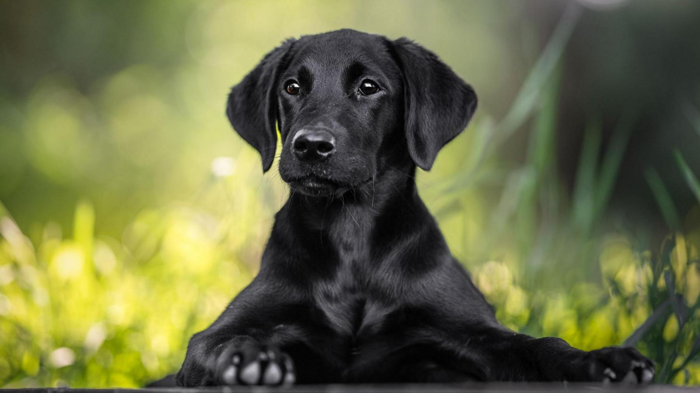

In [ ]:
image_path = "dog.jpg"  # upload this file to the Colab session first

classification_model = "google/vit-base-patch16-224"

classifier = image_classifier(classification_model)

image = Image.open(image_path)
plt.imshow(image)
plt.axis("off")
plt.show()

classification_result = classifier(image_path)
pprint({"Classification result": classification_result})

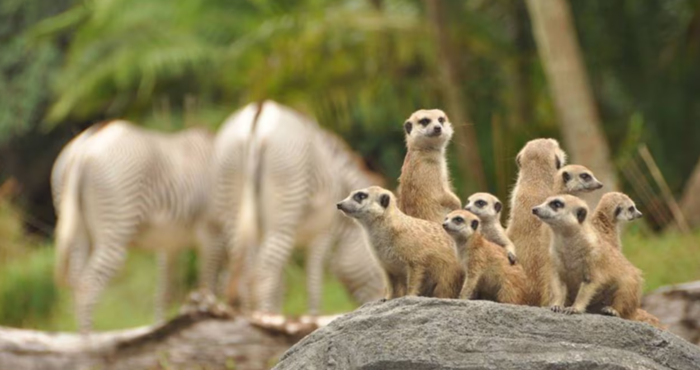

{'Classification result': [{'label': 'meerkat, mierkat', 'score': 0.8086013793945312},
                            {'label': 'mongoose', 'score': 0.13784733414649963},
                            {'label': 'patas, hussar monkey, Erythrocebus patas', 'score': 0.031040875241160393},
                            {'label': 'titi, titi monkey', 'score': 0.004792744293808937},
                            {'label': 'squirrel monkey, Saimiri sciureus', 'score': 0.0023483172990381718}]}


In [ ]:
image_path = "animals.PNG"  # upload this file to the Colab session first

image = Image.open(image_path)
plt.imshow(image)
plt.axis("off")
plt.show()

classification_result = classifier(image_path)
pprint({"Classification result": classification_result})

## Task 9: Image Captioning With BLIP

The last task asks me to generate an actual descriptive sentence about an image, not just a single label. For this I use BLIP, which stands for Bootstrapped Language Image Pretraining. BLIP is a vision language model, meaning it combines an image understanding component with a text generating component in one system.

I deliberately build this one manually rather than reaching for a pipeline shortcut, since the task specifically asks me to load the processor and model, convert the image into tensors, generate captions, and decode them, mirroring the manual approach I used back in Tasks 0 through 4.

A processor for an image model plays the same role a tokenizer plays for text. It resizes the image, normalizes its pixel values, and converts everything into the tensor format the model expects.

I also convert every image to RGB before processing it, using `.convert("RGB")`. This step matters because PNG files, unlike JPG files, sometimes include a fourth transparency channel, called alpha, in addition to red, green, and blue. BLIP's vision encoder expects exactly three color channels, so a PNG with an alpha channel could cause a shape error without this conversion.

Once the image is processed into tensors, `.generate()` produces caption tokens one at a time, the exact same autoregressive idea from Task 7's text generation, except here each new word is conditioned on the image itself instead of a text prompt. Finally, `.decode()` turns those generated token IDs back into a readable sentence, using `skip_special_tokens=True` to remove any leftover technical markers from the output.


In [ ]:
def image_captioner(model, image_path, max_new_tokens):
    """
    Generates a textual description (caption) of a given image using a
    pretrained BLIP Vision-Language Model.

    Args:
        model (str): Name of the pretrained image captioning model to
            use.
        image_path (str): Path to the image file to caption.
        max_new_tokens (int): Maximum number of tokens to generate.

    Returns:
        caption (str): Generated textual description of the image.
    """
    # The processor is the image equivalent of a tokenizer. It prepares
    # raw pixels into the tensor format the model expects.
    processor = transformers.BlipProcessor.from_pretrained(model)

    # BlipForConditionalGeneration is the specific BLIP variant built
    # for generating text conditioned on an image, as opposed to other
    # BLIP variants built for different tasks like image text matching.
    blip_model = transformers.BlipForConditionalGeneration.from_pretrained(model)

    # Convert to RGB to guard against PNG files that include a fourth,
    # transparency channel the model does not expect.
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")

    # Generate caption tokens one at a time, conditioned on the image.
    generated_ids = blip_model.generate(**inputs, max_new_tokens=max_new_tokens)

    # Turn the generated token IDs into a clean, readable sentence.
    caption = processor.decode(generated_ids[0], skip_special_tokens=True)

    return caption

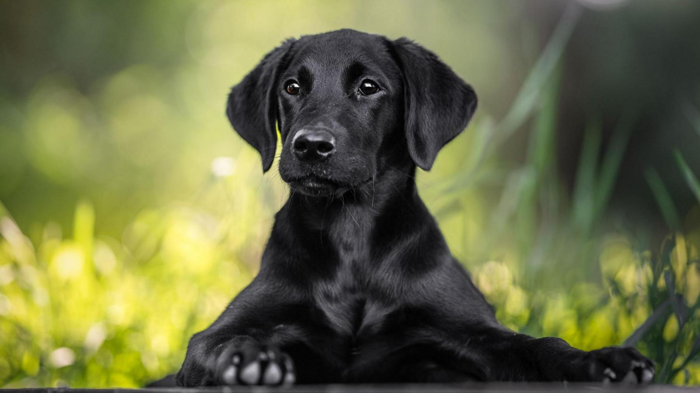

Caption result: a black dog laying on the ground


In [ ]:
image_path = "dog.jpg"  # upload this file to the Colab session first

caption_model = "Salesforce/blip-image-captioning-base"

image = Image.open(image_path)
plt.imshow(image)
plt.axis("off")
plt.show()

caption_result = image_captioner(caption_model, image_path, 50)
print("Caption result:", caption_result)

---
# What I learned from this notebook

Working through these ten tasks taught me a set of ideas that repeat across almost every large language model application, no matter which specific model or task I am using.

**Everything is numbers first.** Text becomes token IDs, images become pixel tensors. A model never actually reads words or sees pictures the way I do. It only ever does math on numbers, and the surrounding code exists to convert my input into those numbers and convert the output back into something readable.

**Architecture decides what a model can do.** An encoder only model like RoBERTa can understand context in both directions at once, which makes it good at filling in missing information but not at generating brand new, flowing text. A decoder only model like GPT-2 can only look backward, which is exactly what allows it to generate new text one word at a time. An encoder-decoder model like MarianMT combines both halves, reading a full source sentence before generating a full target sentence.

**A pipeline is not magic.** Every high level pipeline I used in this notebook, fill-mask, text-generation, and image-classification, is really just a packaged version of the same manual steps I practiced by hand in Part 1: load a model, load a matching tokenizer or processor, convert input to tensors, run the model, and decode the output. Understanding the manual steps meant that when a pipeline was missing in my environment, I was able to rebuild the missing piece myself instead of getting stuck.

**Generation is controllable.** Parameters like temperature, repetition penalty, and no repeat ngram size are not arbitrary settings. Each one adjusts a specific, understandable part of how the model chooses its next word, and learning what each one actually does lets me shape the output intentionally instead of just guessing.

**The same architecture pattern applies beyond text.** Seeing a Vision Transformer treat image patches the same way a text model treats word tokens made the core transformer idea click for me in a way that only reading about text models did not. The attention mechanism does not really care whether it is looking at words or image patches. It only cares about relationships between items in a sequence.

## Key findings from my results

* Masked predictions are strongly influenced by the exact wording around each mask, since RoBERTa uses full bidirectional context to make its guess.
* Dedicated bilingual translation models need no extra input beyond the sentence itself, while genuinely multilingual models need to be told explicitly which language I am translating from and to.
* Lowering temperature during text generation produces safer, more predictable continuations, while raising it produces more varied and sometimes surprising output.
* GPT-2 style models need their padding token manually set to the end of sequence token, since they were never trained with a dedicated padding token to begin with.
* BLIP is able to produce accurate, natural sounding captions directly from raw image pixels, with no manual feature engineering required on my part.

## Author

**Khadija Mustafa** ([@KhadijaTheAnalyst](https://github.com/KhadijaTheAnalyst))
